In [1]:
# Import required library
import pandas as pd

In [2]:
# Load the Superstore dataset
df = pd.read_csv("../datasets/raw/superstore.csv", encoding="latin1")

In [3]:
# ==========================================
# Initial Data Exploration
# ==========================================

In [4]:
# Displays first 5 rows; reveals column names, data format, and obvious patterns
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Returns data types, non-null counts, and memory usage; identifies missing values and casting issues
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
# Returns tuple (rows, columns); essential for understanding dataset size before processing
df.shape

(9994, 21)

In [7]:
# Generates summary statistics (count, mean, std, min, 25%, 50%, 75%, max) for numeric columns; flags outliers
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Check missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [10]:
# Count unique values in categorical columns
df.select_dtypes(include="object").nunique()

C:\Users\Aayush Chauhan\AppData\Local\Temp\ipykernel_21204\3798344476.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
dtype: int64

In [11]:
# ==========================================
# Data Cleaning
# ==========================================

In [12]:
# Check data types of all columns
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [13]:
# Convert date columns to datetime
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])


In [14]:
#Verfiy
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [15]:
# ==========================================
# Exploratory Data Analysis (EDA)
# ==========================================

In [16]:
#Total sales
df["Sales"].sum()

np.float64(2297200.8603)

In [17]:
#Total profit
float(df["Profit"].sum())

286397.0217

In [18]:
# Average Sales
float(df["Sales"].mean())

229.85800083049827

In [19]:
#Average Profit
round(float(df["Profit"].mean()),3)

28.657

In [20]:
# Sales by Category
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [21]:
# Profit by Category
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [22]:
# Sales by Sub-Category
df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64

In [23]:
# Profit by Sub-Category
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [24]:
# Sales by Region
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [25]:
# Profit by Region
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [26]:
# Sales by Segment
df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

In [27]:
# Profit by Segment
df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [28]:
# Top 10 States by Sales
df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

In [29]:
# Top 10 States by Profit
df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64

In [30]:
# ==========================================
# Pivot Table Analysis
# ==========================================

In [31]:
#Sales by Category and Region
df.pivot_table(values="Sales", index="Category", columns="Region", aggfunc=sum)

Region,Central,East,South,West
Category,,,,
Furniture,163797.1638,208291.204,117298.684,252612.7435
Office Supplies,167026.4150,205516.055,125651.313,220853.2490
Technology,170416.3120,264973.981,148771.908,251991.8320


In [32]:
#Profit by Category and Region
df.pivot_table(values="Profit", index="Category", columns="Region", aggfunc=sum)

Region,Central,East,South,West
Category,,,,
Furniture,-2871.0494,3046.1658,6771.2061,11504.9503
Office Supplies,8879.9799,41014.5791,19986.3928,52609.8490
Technology,33697.4320,47462.0351,19991.8314,44303.6496


In [33]:
#Sales by Segment and Category
df.pivot_table(values="Sales", index="Segment", columns="Category", aggfunc="sum")

Category,Furniture,Office Supplies,Technology
Segment,,,
Consumer,391049.3120,363952.136,406399.897
Corporate,229019.7858,230676.462,246450.119
Home Office,121930.6975,124418.434,183304.017


In [34]:
#Average Sales by Category
df.pivot_table(values="Sales", index="Category", aggfunc="mean")

,Sales
Category,
Furniture,349.834887
Office Supplies,119.324101
Technology,452.709276


In [35]:
#Total Quantity Sold
df.pivot_table(values="Quantity", index="Category", columns="Region", aggfunc="sum")

Region,Central,East,South,West
Category,,,,
Furniture,1827,2214,1291,2696
Office Supplies,5409,6462,3800,7235
Technology,1544,1942,1118,2335


In [36]:
# ==========================================
# Data Visualization
# ==========================================

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

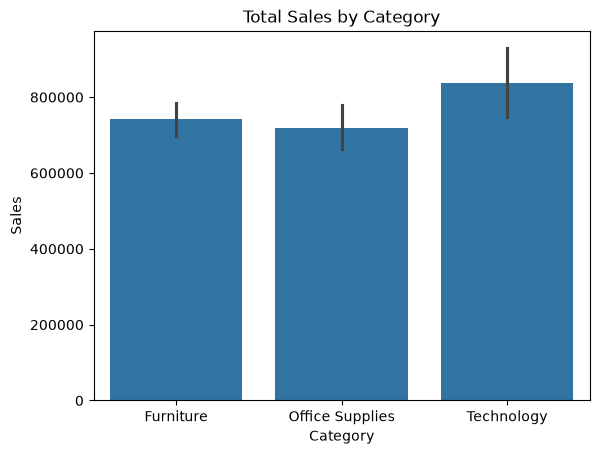

In [38]:
# Sales by Category
sns.barplot(data=df, x="Category", y="Sales", estimator="sum")
plt.title("Total Sales by Category")
plt.show()

#Insights: Technology ki total sales sabse zyada hai, uske baad Furniture, aur Office Supplies ki sabse kam.

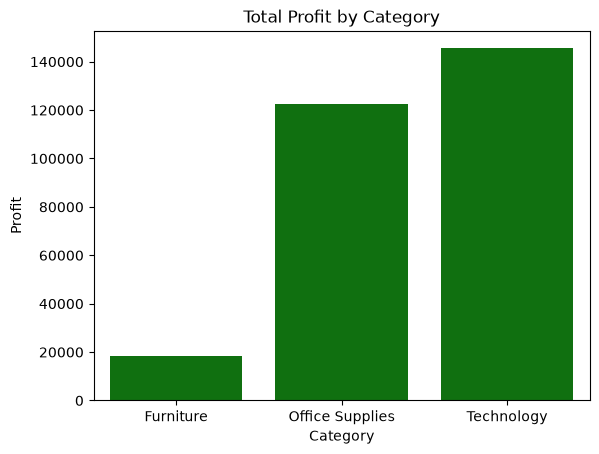

In [39]:
#Profit by Category
sns.barplot(data=df, x="Category", y="Profit", estimator="sum", errorbar=None, color="green")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

#Insights: Technology generates the highest profit, while Furniture generates the lowest profit.

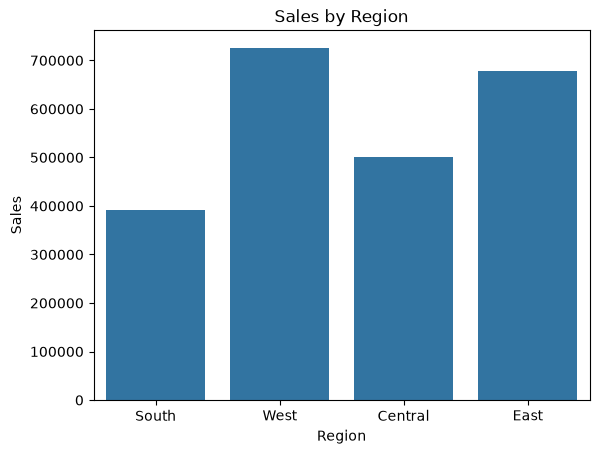

In [40]:
#Sales by Region
sns.barplot(data=df, x="Region", y="Sales", estimator="sum", errorbar=None)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

#Insights: West region has the highest sales, while South has the lowest sales.

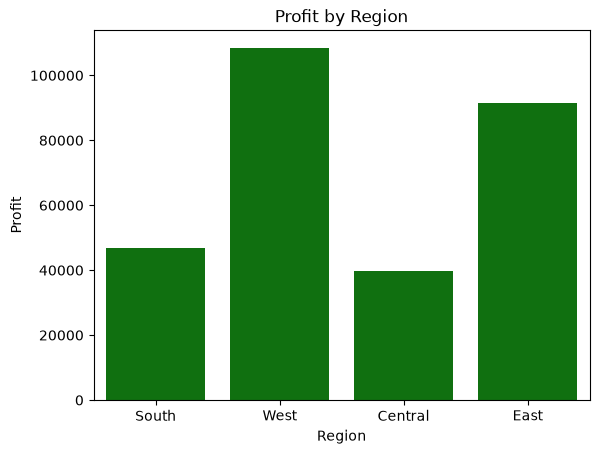

In [41]:
# Profit by Region

sns.barplot(data=df, x="Region", y="Profit", estimator="sum", errorbar=None, color="green")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

#Insight: West region has the highest profit, while Central has the lowest profit.

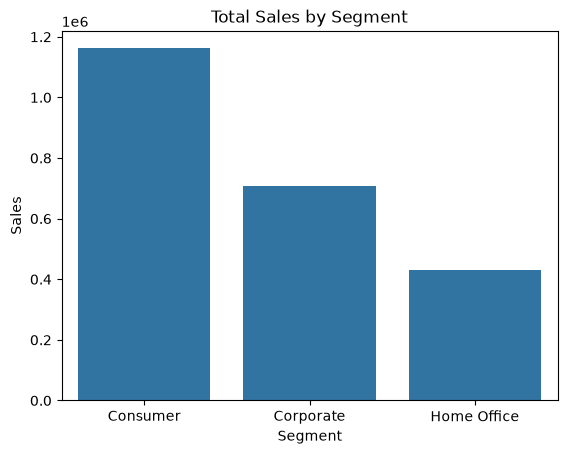

In [42]:
# Sales by Segment
sns.barplot(data=df, x="Segment", y="Sales", estimator="sum", errorbar=None)

plt.title("Total Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()

#Insight: Consumer segment has the highest sales, while Home Office has the lowest.

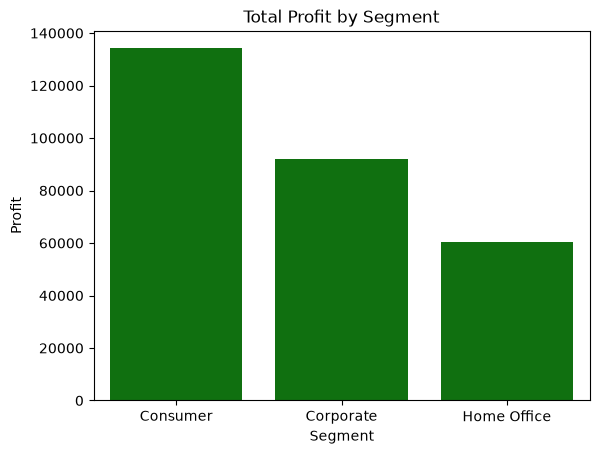

In [43]:
# Profit by Segment
sns.barplot(data=df, x="Segment", y="Profit", estimator="sum", errorbar=None, color="green")

plt.title("Total Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.show()

#Insights: Consumer Segment having highest profit while Homw Office having lowest, so increase sales

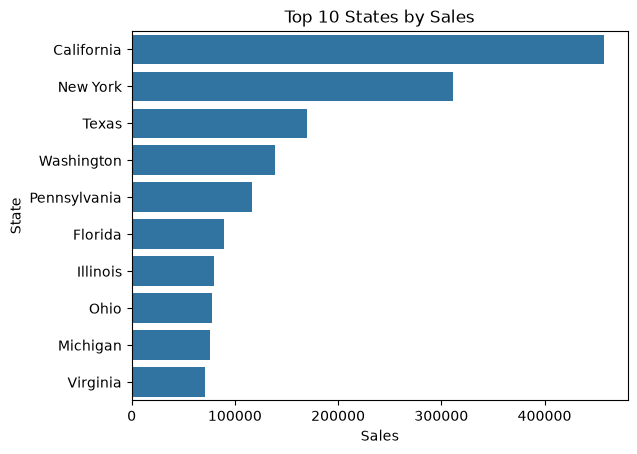

In [44]:
# Top 10 States by Sales
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")
plt.show()

#Insight: California has the highest sales, while Virginia has the lowest among the top 10 states.

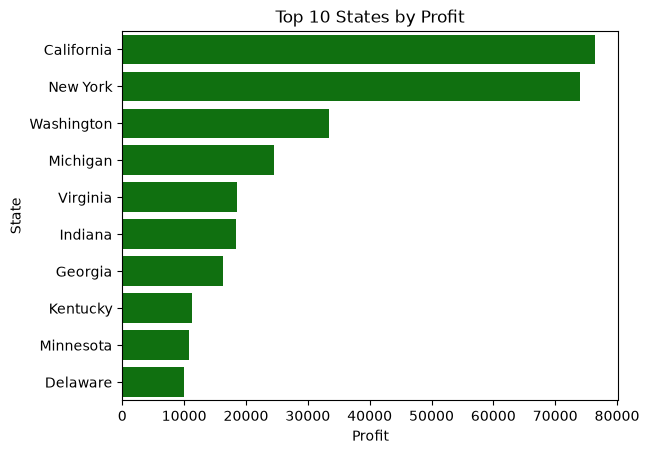

In [45]:
#Top 10 States by Profit
top_profit_states = df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_profit_states.values, y=top_profit_states.index, color="green")
plt.title("Top 10 States by Profit")
plt.xlabel("Profit")
plt.ylabel("State")
plt.show()

#Insight: California has the highest profit, while Delaware has the lowest among the top 10 states.

In [46]:
# Convert Order Date to datetime as Order Date is not datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Order Date"].dtype #to verify

# Create Month column
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

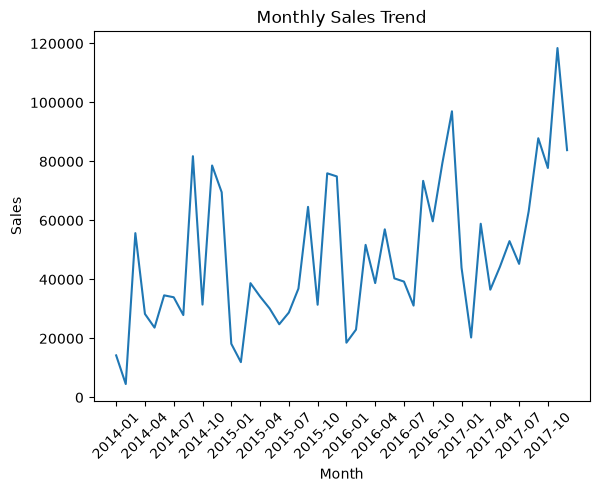

<Figure size 1500x1000 with 0 Axes>

In [47]:
# Monthly Sales Trend
monthly_sales = df.groupby("Month")["Sales"].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
#har 3rd month k hi label dikho
plt.xticks(range(0, len(monthly_sales), 3), monthly_sales.index[::3],rotation=45)

plt.figure(figsize=(15, 10))
plt.show()

#Insight: Monthly sales fluctuate karti hain, but overall sales trend 2014 se 2017 tak upward hai, with the highest peak in 2017.

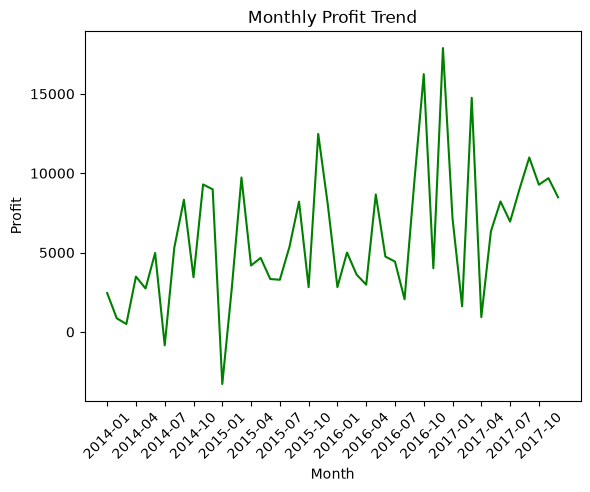

In [48]:
#Monthly Profit Trend

monthly_profit = df.groupby("Month")["Profit"].sum();

sns.lineplot(x=monthly_profit.index, y=monthly_profit.values, color="green")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(
    range(0, len(monthly_profit), 3),
    monthly_profit.index[::3],
    rotation=45
)

plt.show()

#Insight: Profit me kaafi fluctuations hain, lekin overall trend upward hai; highest profit peak 2016 ke second half me dikhta hai.

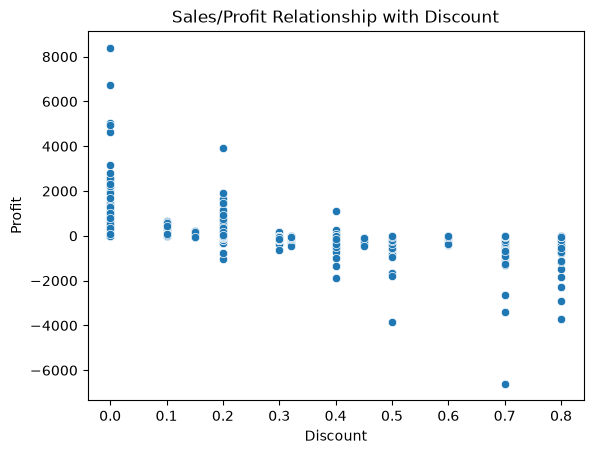

In [49]:
# Sales vs Profit by Discount
sns.scatterplot(data=df, x="Discount", y="Profit")

plt.title("Sales/Profit Relationship with Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

# Insight: Discount badhne ke saath profit generally decrease hota hai; high discounts (50%+) par losses zyada dikh rahe hain.

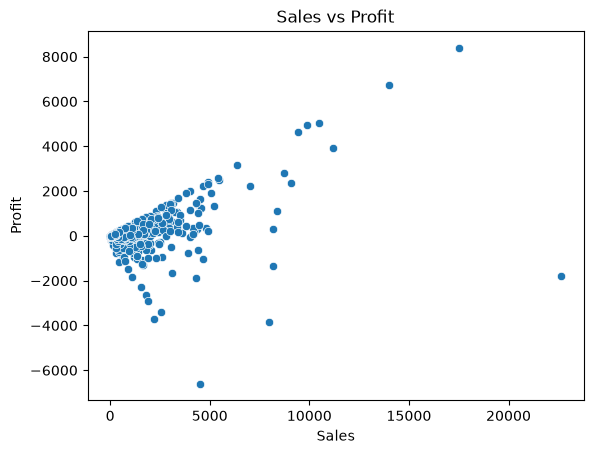

In [50]:
#Sales vs Profit
sns.scatterplot(data=df, x="Sales", y="Profit")

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

# Insights: Sales generally increase with Profit, but some high-sales orders still generate losses, indicating the impact of discounts/costs.

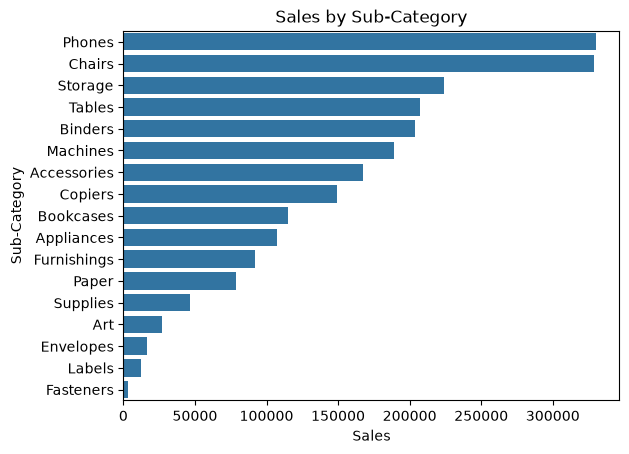

In [51]:
# Sales by Sub-Category
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

sns.barplot(x=subcat_sales.values, y=subcat_sales.index)
plt.title("Sales by Sub-Category")
plt.xlabel("Sales")
plt.ylabel("Sub-Category")

plt.show()
#Insight: Phones aur Chairs ki sales sabse highest hain, jabki Fasteners ki sales sabse lowest hai.

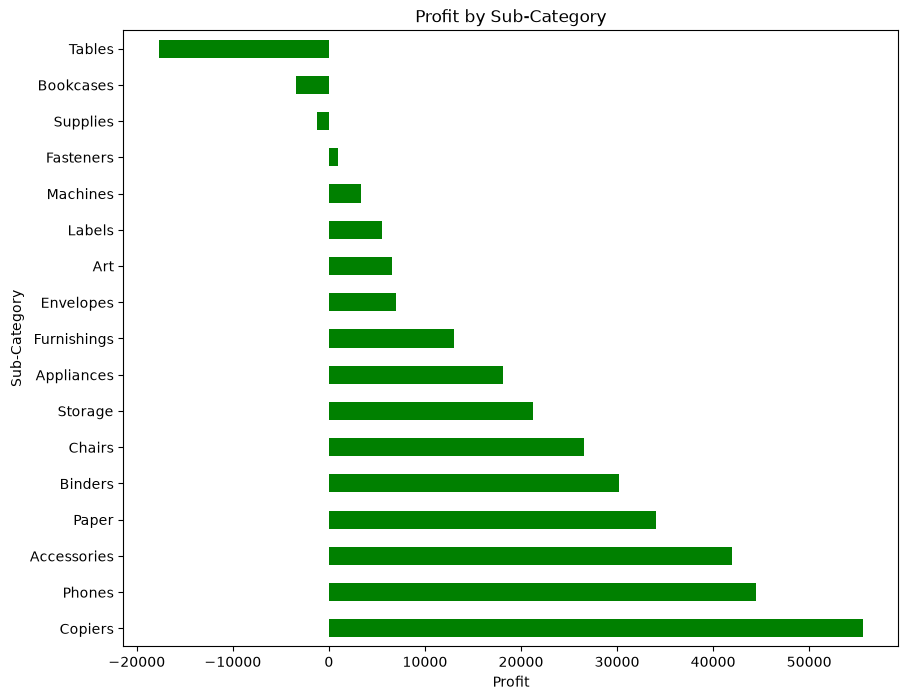

In [52]:
#Profit by Sub-Category
profit_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))
profit_subcat.plot(kind="barh", color="green") #bargroah k another meth
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

#Insight: Copiers ka profit sabse highest hai, jabki Tables sabse lowest aur negative profit de raha hai.


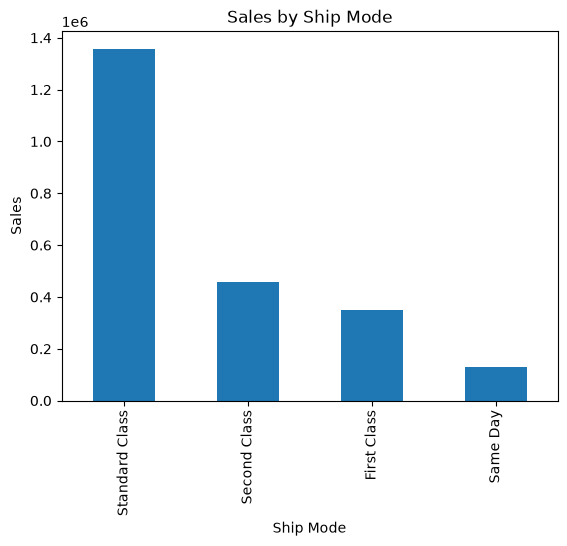

In [53]:
#Sales by Ship Mode
sales_ship = df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)

sales_ship.plot(kind="bar")
plt.title("Sales by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Sales")
plt.show()

#Insight: Standard Class generates the highest sales, while Same Day has the lowest sales.

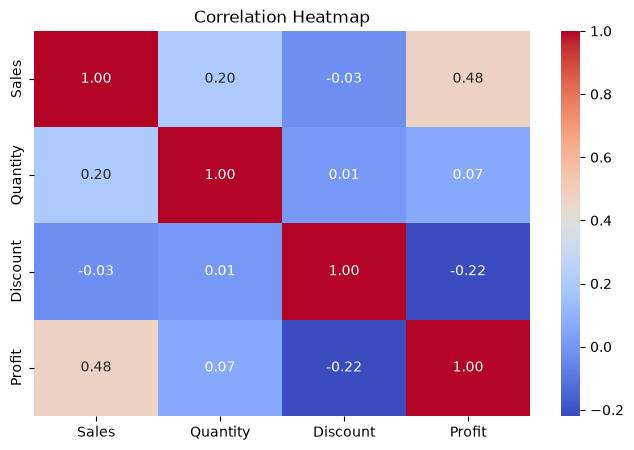

In [54]:
# Heatmap / Correlation Analysis (btw Sales, Quantity, Discount aur Profit)

corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
#corr()-to calc correlation btw columns ; +1 for strong +ve relationship , 0 - no linear rel , -1 strong -ve rel

#create heapmap
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
# annot=True → har box ke andar correlation value bhi likhta hai; fmt=".2f" → values ko 2 decimal places tak dikhata hai.

plt.title("Correlation Heatmap")
plt.show()

#Insights: Sales has the strongest positive relationship with Profit, while higher discounts show a negative impact on profitability.

In [55]:
# Final KPI Summary

print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Average Profit:", df["Profit"].mean())
print("Total Quantity:", df["Quantity"].sum())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Average Profit: 28.65689630778467
Total Quantity: 37873


In [56]:
# Best performing Category
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [57]:
# Best performing Region
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [58]:
# Best performing Segment
df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

In [59]:
# Best profitable Sub-Category
df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64

In [60]:
### Final Data Quality Check

In [61]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())
print("\nDataset Shape:", df.shape)

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Month            0
dtype: int64

Duplicate Rows: 0

Dataset Shape: (9994, 22)


In [63]:
## Overall EDA Insights

# Category → Technology highest Sales & Profit
# Region → West highest Profit
# Segment → Consumer highest Sales & Profit
# State → California highest Sales & Profit
# Sub-category → Phones highest Sales, Copiers highest Profit
# Ship Mode → Standard Class highest Sales
# Monthly trend → sales/profit fluctuate but overall sales growth visible
# Discount → higher discount has negative relationship with Profit
# Sales ↔ Profit → moderate positive relationship